# Active Learning Results — Visualization

**Project:** Molecular Active Learning for HIV Drug Discovery  
**Produces:** Learning curves (AUPRC, AUROC, Hit Recovery) + sample efficiency tables  

## Data structure expected
Each Excel file has tabs named: `rf_random`, `rf_entropy`, `rf_density`, `rf_diversity`, `rf_weighted`, `rf_bald`  
Each tab has columns: `Step` (0-47), then three seed columns e.g. `RF_weighted-seed0 - al/auprc`

**Files:**
- `preprocessing/data/rf_auprc_all_seeds.xlsx`
- `preprocessing/data/rf_auroc_all_seeds.xlsx`
- `preprocessing/data/rf_hit_recovery_all_seeds.xlsx`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_DIR    = 'preprocessing/data'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

AUPRC_FILE  = os.path.join(DATA_DIR, 'rf_auprc_all_seeds.xlsx')
AUROC_FILE  = os.path.join(DATA_DIR, 'rf_auroc_all_seeds.xlsx')
HITS_FILE   = os.path.join(DATA_DIR, 'rf_hit_recovery_all_seeds.xlsx')

# ── Experiment config ─────────────────────────────────────────────────────
# Molecules at each AL step: init=5757, batch=500, 47 iterations
N_INIT    = 5757
BATCH     = 500
POOL_SIZE = 28788
N_STEPS   = 48  # 0-indexed steps (0..47)

# Step index → number of labeled molecules
STEP_TO_LABELED = {i: N_INIT + i * BATCH for i in range(N_STEPS)}

# Offline (passive) RF AUPRC and AUROC — from Cell A4 results
PASSIVE_AUPRC = 0.3799
PASSIVE_AUROC = 0.7907

# ── Conditions to plot ────────────────────────────────────────────────────
CONDITIONS = {
    'rf_random':    {'label':'Random Acquisition (model, random queries)',          'color': '#808080', 'linestyle': ':',  'zorder': 1},
    'rf_entropy':   {'label': 'Shannon Entropy',  'color': '#1f77b4', 'linestyle': '-',  'zorder': 3},
    'rf_diversity': {'label': 'Diversity',         'color': '#9467bd', 'linestyle': '--', 'zorder': 2},
    'rf_density':   {'label': 'Density',           'color': '#8c564b', 'linestyle': '-.', 'zorder': 2},
    'rf_weighted':  {'label': 'Weighted Entropy',  'color': '#d62728', 'linestyle': '-',  'zorder': 4},
    'rf_bald':      {'label': 'BALD',              'color': '#ff7f0e', 'linestyle': '-',  'zorder': 4},
}

print(f'Config loaded.')
print(f'  Pool size      : {POOL_SIZE:,}')
print(f'  Init labeled   : {N_INIT:,}')
print(f'  Batch size     : {BATCH}')
print(f'  AL iterations  : {N_STEPS - 1}')
print(f'  Passive AUPRC  : {PASSIVE_AUPRC}')
print(f'  Passive AUROC  : {PASSIVE_AUROC}')

Config loaded.
  Pool size      : 28,788
  Init labeled   : 5,757
  Batch size     : 500
  AL iterations  : 47
  Passive AUPRC  : 0.3799
  Passive AUROC  : 0.7907


In [3]:
import pandas as pd
import numpy as np
import json
import os
import wandb

# ── Helper functions ──────────────────────────────────────────────────────

def load_metric_file(filepath):
    """Load all sheets from an Excel file, skipping empty ones."""
    all_sheets = pd.read_excel(filepath, sheet_name=None, index_col=None)
    result = {}
    for sheet_name, df in all_sheets.items():
        if df.empty or len(df.columns) < 2:
            print(f"  SKIPPING '{sheet_name}': empty or too few columns")
            continue
        cols = df.columns.tolist()
        rename = {cols[0]: 'step'}
        for i, c in enumerate(cols[1:]):
            rename[c] = f'seed{i}'
        df = df.rename(columns=rename)
        try:
            df['step'] = pd.to_numeric(df['step'], errors='coerce')
            df = df.dropna(subset=['step'])
            df['step'] = df['step'].astype(int)
        except Exception as e:
            print(f"  SKIPPING '{sheet_name}': {e}")
            continue
        if len(df) == 0:
            continue
        df['n_labeled'] = df['step'].map(lambda s: N_INIT + s * BATCH)
        result[sheet_name] = df
        print(f"  Loaded '{sheet_name}': {len(df)} rows")
    return result


def get_mean_std(df):
    """Compute mean and std across seed columns."""
    seed_cols = [c for c in df.columns if c.startswith('seed')]
    df = df.copy().sort_values('n_labeled')
    df['mean'] = df[seed_cols].mean(axis=1)
    df['std']  = df[seed_cols].std(axis=1)
    return df


# ── Step 1: Load Excel files ──────────────────────────────────────────────
print('Loading Excel files...')
auprc_data = load_metric_file(AUPRC_FILE)
auroc_data = load_metric_file(AUROC_FILE)
hits_data  = load_metric_file(HITS_FILE)
print(f'Sheets from Excel: {list(auprc_data.keys())}')

# ── Step 2: Load RF BALD from local JSON cache if it exists ───────────────
# (avoids re-fetching from WandB every session once saved)

def _bald_df_from_dict(d):
    return pd.DataFrame({
        'step':     range(len(d['n_labeled'])),
        'seed0':    d['seed0'],
        'seed1':    d['seed1'],
        'seed2':    d['seed2'],
        'n_labeled': d['n_labeled'],
    })

bald_cache_ok = all(
    os.path.exists(os.path.join(RESULTS_DIR, f'rf_bald_{m}.json'))
    for m in ['auprc', 'auroc', 'hits']
)

if bald_cache_ok:
    print('Loading RF BALD from local JSON cache...')
    for metric, data_dict in [('auprc', auprc_data),
                               ('auroc', auroc_data),
                               ('hits',  hits_data)]:
        path = os.path.join(RESULTS_DIR, f'rf_bald_{metric}.json')
        with open(path) as f:
            d = json.load(f)
        data_dict['rf_bald'] = _bald_df_from_dict(d)
        print(f"  rf_bald ({metric}): {len(data_dict['rf_bald'])} rows")
else:
    # ── Step 3: Fetch RF BALD from WandB ─────────────────────────────────
    print('Fetching RF BALD from WandB (this takes ~30s)...')
    api = wandb.Api()

    RF_BALD_RUNS = {
        'seed0': '48n6tbbr',
        'seed1': '8duvvl8b',
        'seed2': 'hmlezaly',
    }

    run_histories = {}
    for seed_name, run_id in RF_BALD_RUNS.items():
        run = api.run(f"CMU_Automation_S26/CMU_Automation_S26/{run_id}")
        hist = run.history(
            keys=['al/auprc', 'al/auroc', 'al/hit_recovery', 'al/n_labeled'],
            pandas=True,
        )
        print(f"  {seed_name} ({run_id}): {len(hist)} rows, "
              f"cols={hist.columns.tolist()}")
        run_histories[seed_name] = hist

    # Reconstruct n_labeled
    sample = list(run_histories.values())[0].dropna(subset=['al/auprc'])
    use_logged_n = 'al/n_labeled' in sample.columns
    print(f"  Using logged n_labeled: {use_logged_n}")

    seeds = {'auprc': {}, 'auroc': {}, 'hits': {}}
    n_labeled_col = None

    for seed_name, hist in run_histories.items():
        hist = hist.dropna(subset=['al/auprc']).reset_index(drop=True)
        if use_logged_n:
            n_labeled_col = hist['al/n_labeled'].values.astype(int)
        else:
            n_labeled_col = np.array([N_INIT + i * BATCH for i in range(len(hist))])
        seeds['auprc'][seed_name] = hist['al/auprc'].values
        seeds['auroc'][seed_name] = hist['al/auroc'].values
        seeds['hits'][seed_name]  = hist['al/hit_recovery'].values
        print(f"  {seed_name}: {len(hist)} iters, "
              f"final AUPRC={hist['al/auprc'].iloc[-1]:.4f}, "
              f"final hits={hist['al/hit_recovery'].iloc[-1]:.4f}")

    n_rows = len(list(seeds['auprc'].values())[0])
    if n_labeled_col is None or len(n_labeled_col) != n_rows:
        n_labeled_col = np.array([N_INIT + i * BATCH for i in range(n_rows)])

    # Inject into data dicts and save JSON cache
    for metric, data_dict in [('auprc', auprc_data),
                               ('auroc', auroc_data),
                               ('hits',  hits_data)]:
        df = pd.DataFrame({
            'step':     range(n_rows),
            'seed0':    seeds[metric]['seed0'],
            'seed1':    seeds[metric]['seed1'],
            'seed2':    seeds[metric]['seed2'],
            'n_labeled': n_labeled_col,
        })
        data_dict['rf_bald'] = df

        path = os.path.join(RESULTS_DIR, f'rf_bald_{metric}.json')
        with open(path, 'w') as f:
            json.dump({
                'n_labeled': n_labeled_col.tolist(),
                'seed0': seeds[metric]['seed0'].tolist(),
                'seed1': seeds[metric]['seed1'].tolist(),
                'seed2': seeds[metric]['seed2'].tolist(),
            }, f)
        print(f"  Saved cache: {path}")

# ── Verify ────────────────────────────────────────────────────────────────
print(f'\nFinal conditions in auprc_data: {list(auprc_data.keys())}')
bald_check = get_mean_std(auprc_data['rf_bald'])
print(f'RF BALD AUPRC: first={bald_check["mean"].iloc[0]:.4f}, '
      f'last={bald_check["mean"].iloc[-1]:.4f}')
print(f'RF BALD n_labeled: {bald_check["n_labeled"].iloc[0]} → '
      f'{bald_check["n_labeled"].iloc[-1]}')


Loading Excel files...
  Loaded 'rf_density': 48 rows
  Loaded 'rf_diversity': 48 rows
  Loaded 'rf_random': 48 rows
  Loaded 'rf_weighted': 48 rows
  Loaded 'rf_entropy': 48 rows
  SKIPPING 'rf_bald': empty or too few columns
  Loaded 'rf_density': 48 rows
  Loaded 'rf_diversity': 48 rows
  Loaded 'rf_random': 48 rows
  Loaded 'rf_weighted': 48 rows
  Loaded 'rf_entropy': 48 rows
  SKIPPING 'rf_bald': empty or too few columns
  Loaded 'rf_density': 48 rows
  Loaded 'rf_diversity': 48 rows
  Loaded 'rf_random': 48 rows
  Loaded 'rf_weighted': 48 rows
  Loaded 'rf_entropy': 48 rows
  SKIPPING 'rf_bald': empty or too few columns
Sheets from Excel: ['rf_density', 'rf_diversity', 'rf_random', 'rf_weighted', 'rf_entropy']
Loading RF BALD from local JSON cache...
  rf_bald (auprc): 48 rows
  rf_bald (auroc): 48 rows
  rf_bald (hits): 48 rows

Final conditions in auprc_data: ['rf_density', 'rf_diversity', 'rf_random', 'rf_weighted', 'rf_entropy', 'rf_bald']
RF BALD AUPRC: first=0.2709, last=0

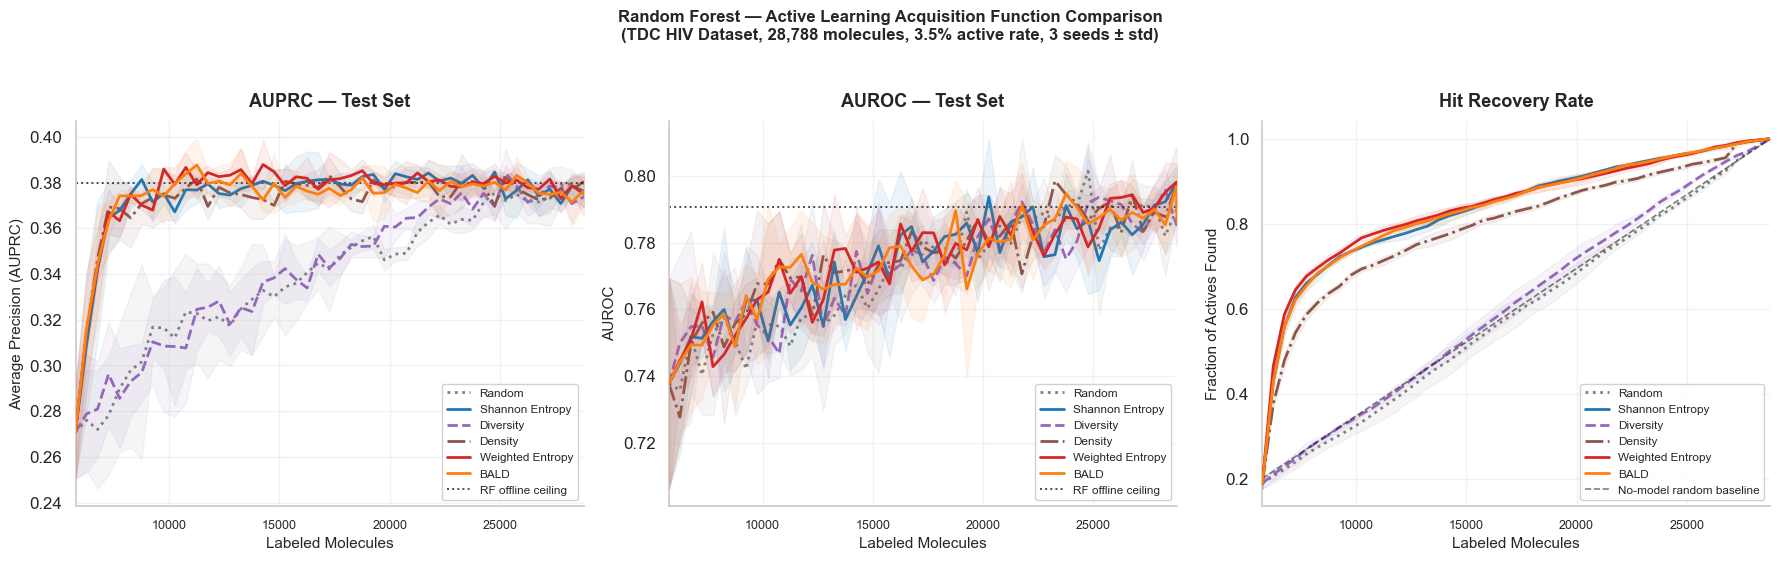

Saved: results/rf_learning_curves.png


In [14]:
# ── Figure 1: Learning Curves (AUPRC, AUROC, Hit Recovery) ───────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

metric_configs = [
    (auprc_data, axes[0], 'AUPRC — Test Set', 'Average Precision (AUPRC)',
     PASSIVE_AUPRC, 'RF offline ceiling'),
    (auroc_data, axes[1], 'AUROC — Test Set', 'AUROC',
     PASSIVE_AUROC, 'RF offline ceiling'),
    (hits_data, axes[2], 'Hit Recovery Rate', 'Fraction of Actives Found',
     None, None),
]

for data_dict, ax, title, ylabel, passive_val, passive_label in metric_configs:
    for cond_key, style in CONDITIONS.items():
        if cond_key not in data_dict:
            continue
        df = get_mean_std(data_dict[cond_key])
        x    = df['n_labeled'].values
        mean = df['mean'].values
        std  = df['std'].values

        ax.plot(x, mean,
                label=style['label'],
                color=style['color'],
                linestyle=style['linestyle'],
                linewidth=2.0,
                zorder=style['zorder'])
        ax.fill_between(x, mean - std, mean + std,
                        color=style['color'],
                        alpha=0.08,  # very light band to avoid crowding
                        zorder=style['zorder'] - 1)

    # Passive ceiling
    if passive_val is not None:
        ax.axhline(passive_val, color='black', linestyle=':',
                   linewidth=1.4, alpha=0.7, label=passive_label)

    # Random baseline for hit recovery
    if title == 'Hit Recovery Rate':
        x_range = np.linspace(N_INIT, POOL_SIZE, 200)
        ax.plot(x_range, x_range / POOL_SIZE, color='black',
                linestyle='--', linewidth=1.2, alpha=0.5, label='No-model random baseline')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Labeled Molecules', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=8.5, framealpha=0.9, loc='lower right')
    ax.set_xlim(N_INIT, POOL_SIZE)
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle(
    'Random Forest — Active Learning Acquisition Function Comparison\n'
    f'(TDC HIV Dataset, {POOL_SIZE:,} molecules, 3.5% active rate, 3 seeds ± std)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'rf_learning_curves.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

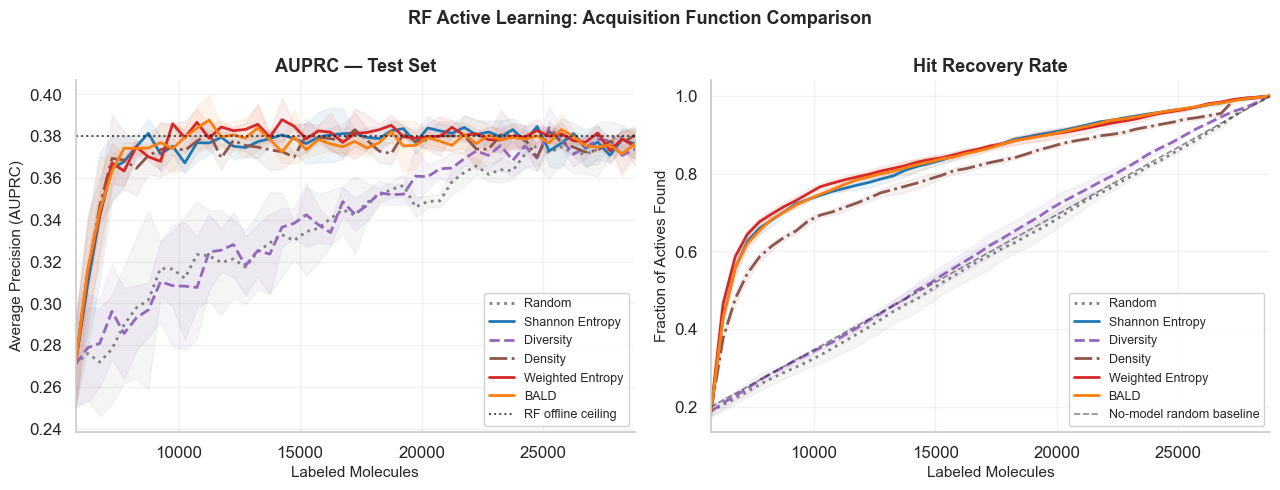

Saved: results/rf_auprc_hits_2panel.png


In [15]:
# ── Figure 2: AUPRC + Hit Recovery side by side (paper-ready 2-panel) ────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for data_dict, ax, title, ylabel, passive_val in [
    (auprc_data, axes[0], 'AUPRC — Test Set', 'Average Precision (AUPRC)', PASSIVE_AUPRC),
    (hits_data,  axes[1], 'Hit Recovery Rate', 'Fraction of Actives Found', None),
]:
    for cond_key, style in CONDITIONS.items():
        if cond_key not in data_dict:
            continue
        df = get_mean_std(data_dict[cond_key])
        ax.plot(df['n_labeled'], df['mean'],
                label=style['label'], color=style['color'],
                linestyle=style['linestyle'], linewidth=2.0)
        ax.fill_between(df['n_labeled'],
                        df['mean'] - df['std'],
                        df['mean'] + df['std'],
                        color=style['color'], alpha=0.08)

    if passive_val is not None:
        ax.axhline(passive_val, color='black', linestyle=':', lw=1.4,
                   alpha=0.7, label='RF offline ceiling')

    if title == 'Hit Recovery Rate':
        x_r = np.linspace(N_INIT, POOL_SIZE, 200)
        ax.plot(x_r, x_r / POOL_SIZE, 'k--', lw=1.2, alpha=0.5,
        label='No-model random baseline')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Labeled Molecules', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.set_xlim(N_INIT, POOL_SIZE)
    ax.grid(True, alpha=0.25)

plt.suptitle('RF Active Learning: Acquisition Function Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'rf_auprc_hits_2panel.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

In [5]:
# ── Sample Efficiency Analysis ────────────────────────────────────────────

def compute_sample_efficiency(passive_auprc, pool_size):
    """
    For each condition with data, compute:
    - n_labeled needed to reach X% of passive AUPRC ceiling
    - hit recovery at fixed labeling budgets
    """
    rows = []
    for cond_key, style in CONDITIONS.items():
        # Skip conditions with no data in EITHER auprc or hits
        if cond_key not in auprc_data or cond_key not in hits_data:
            continue

        df_auprc = get_mean_std(auprc_data[cond_key])
        df_hits  = get_mean_std(hits_data[cond_key])

        x_a    = df_auprc['n_labeled'].values
        mean_a = df_auprc['mean'].values
        x_h    = df_hits['n_labeled'].values
        mean_h = df_hits['mean'].values

        row = {'Condition': style['label']}

        # n_labeled to reach X% of passive AUPRC
        for t in [0.6, 0.7, 0.8, 0.9]:
            target = t * passive_auprc
            idx    = np.where(mean_a >= target)[0]
            col    = f'AUPRC≥{int(t*100)}%\n(≥{target:.3f})'
            row[col] = f"{x_a[idx[0]]:,}" if len(idx) > 0 else "—"

        # Hit recovery at fixed budgets
        for pct in [0.20, 0.30, 0.40, 0.50]:
            budget = int(pct * pool_size)
            val    = float(np.interp(budget, x_h, mean_h))
            row[f'Hits@{int(pct*100)}%\npool'] = f'{val:.1%}'

        rows.append(row)

    df = pd.DataFrame(rows).set_index('Condition')
    return df


efficiency_df = compute_sample_efficiency(PASSIVE_AUPRC, POOL_SIZE)
print(f'Offline (Passive) RF AUPRC: {PASSIVE_AUPRC}')
print(f'Offline (Passive) RF AUROC: {PASSIVE_AUROC}')
print(f'Conditions included: {efficiency_df.index.tolist()}')
print()
display(efficiency_df)


Offline (Passive) RF AUPRC: 0.3799
Offline (Passive) RF AUROC: 0.7907
Conditions included: ['Random', 'Shannon Entropy', 'Diversity', 'Density', 'Weighted Entropy', 'BALD']



,AUPRC≥60%\n(≥0.228),AUPRC≥70%\n(≥0.266),AUPRC≥80%\n(≥0.304),AUPRC≥90%\n(≥0.342),Hits@20%\npool,Hits@30%\npool,Hits@40%\npool,Hits@50%\npool
Condition,,,,,,,,
Random,"5,757","5,757","9,257","16,757",18.9%,28.5%,37.8%,48.4%
Shannon Entropy,"5,757","5,757","6,257","7,257",18.9%,69.7%,76.6%,82.1%
Diversity,"5,757","5,757","9,257","15,257",18.9%,29.9%,39.4%,50.6%
Density,"5,757","5,757","6,257","6,757",18.9%,63.0%,71.9%,77.9%
Weighted Entropy,"5,757","5,757","6,257","6,757",18.9%,71.0%,78.8%,83.2%
BALD,"5,757","5,757","6,257","6,757",18.9%,69.7%,77.9%,82.5%


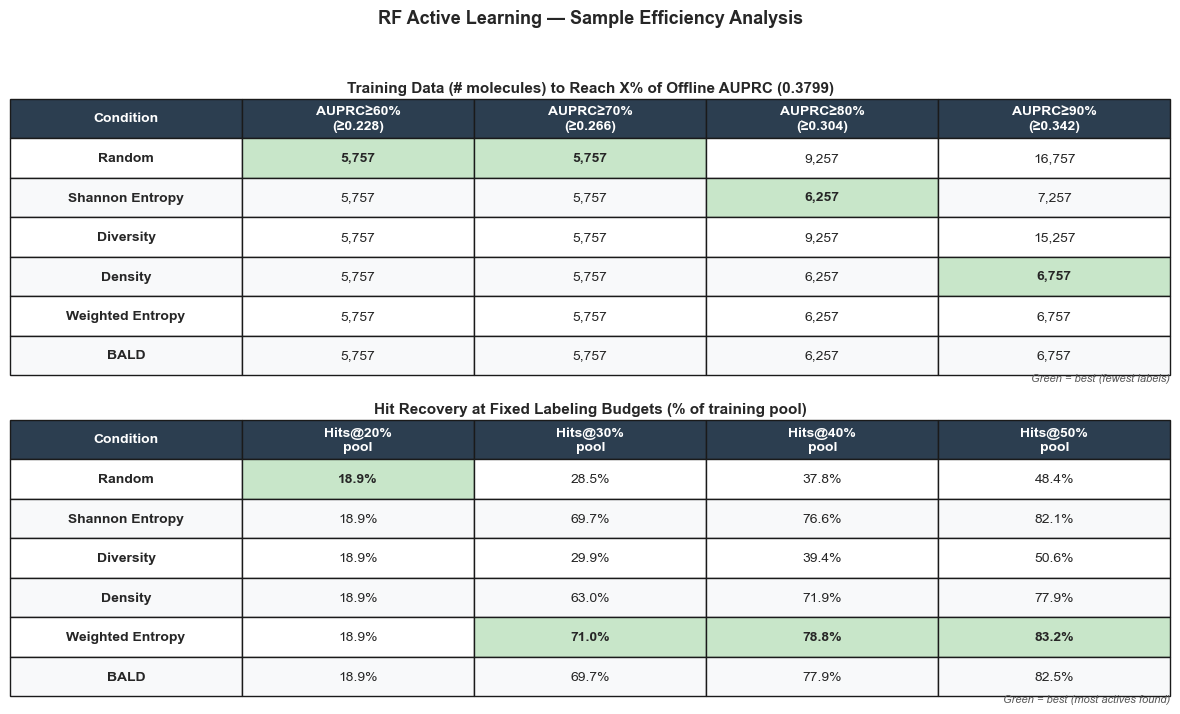

Saved: results/rf_efficiency_tables.png


In [6]:
# ── Figure 3: Sample Efficiency Tables as Figures ─────────────────────────

def style_efficiency_table(df):
    """Apply consistent styling to efficiency table."""
    return (df.style
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('background-color', '#2c3e50'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '8px'),
                ('font-size', '11px'),
            ]},
            {'selector': 'td', 'props': [
                ('text-align', 'center'),
                ('padding', '6px 10px'),
                ('font-size', '11px'),
            ]},
            {'selector': 'tr:nth-child(even)', 'props': [
                ('background-color', '#f8f9fa'),
            ]},
        ])
        .highlight_min(axis=0, color='#d4edda',  # green = best (fewest labels needed)
                       subset=[c for c in df.columns if 'AUPRC' in c])
        .highlight_max(axis=0, color='#d4edda',  # green = best (most hits)
                       subset=[c for c in df.columns if 'Hits' in c])
    )

# Split into two sub-tables for clarity
auprc_cols = [c for c in efficiency_df.columns if 'AUPRC' in c]
hits_cols  = [c for c in efficiency_df.columns if 'Hits' in c]

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

for ax, cols, title, note in [
    (axes[0], auprc_cols,
     f'Training Data (# molecules) to Reach X% of Offline AUPRC ({PASSIVE_AUPRC:.4f})',
     'Green = best (fewest labels)'),
    (axes[1], hits_cols,
     'Hit Recovery at Fixed Labeling Budgets (% of training pool)',
     'Green = best (most actives found)'),
]:
    ax.axis('off')
    sub_df = efficiency_df[cols].reset_index()
    table = ax.table(
        cellText=sub_df.values,
        colLabels=sub_df.columns,
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    # Style header row
    for j in range(len(sub_df.columns)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Style condition (first) column
    for i in range(1, len(sub_df) + 1):
        table[i, 0].set_text_props(fontweight='bold')
        # Alternate row shading
        shade = '#f8f9fa' if i % 2 == 0 else 'white'
        for j in range(len(sub_df.columns)):
            table[i, j].set_facecolor(shade)

    # Highlight best values (min for AUPRC cols, max for Hits cols)
    if 'AUPRC' in cols[0]:
        for j_idx, col in enumerate(cols, start=1):
            vals = []
            for i in range(1, len(sub_df) + 1):
                v = table[i, j_idx].get_text().get_text()
                try:
                    vals.append((i, int(v.replace(',', ''))))
                except:
                    vals.append((i, float('inf')))
            best_i = min(vals, key=lambda x: x[1])[0]
            table[best_i, j_idx].set_facecolor('#c8e6c9')
            table[best_i, j_idx].set_text_props(fontweight='bold')
    else:
        for j_idx, col in enumerate(cols, start=1):
            vals = []
            for i in range(1, len(sub_df) + 1):
                v = table[i, j_idx].get_text().get_text()
                try:
                    vals.append((i, float(v.strip('%')) / 100))
                except:
                    vals.append((i, -1))
            best_i = max(vals, key=lambda x: x[1])[0]
            table[best_i, j_idx].set_facecolor('#c8e6c9')
            table[best_i, j_idx].set_text_props(fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold', pad=5)
    ax.text(1.0, -0.02, note, transform=ax.transAxes,
            fontsize=8, ha='right', color='#555', style='italic')

plt.suptitle('RF Active Learning — Sample Efficiency Analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'rf_efficiency_tables.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

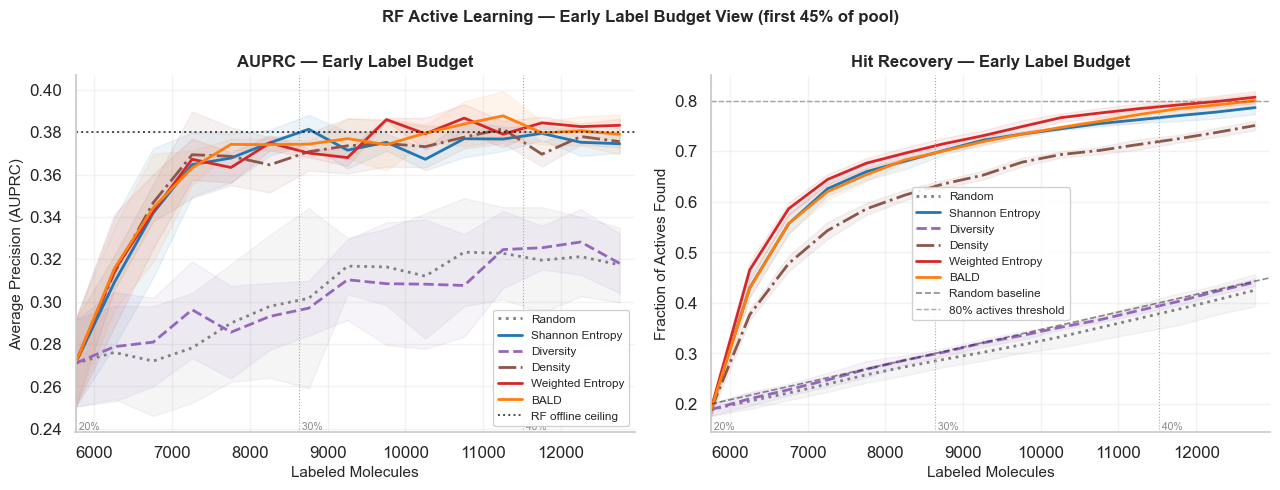

Saved: results/rf_early_budget_zoom.png


In [ ]:
# ── Figure 4: Hit recovery zoomed into the most important budget range ────
# Drug discovery campaigns typically have budget ≤ 40% of pool
# This zoomed view makes the early-iteration differences more visible

BUDGET_MAX = int(0.45 * POOL_SIZE)  # zoom to first 45% of pool

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data_dict, ylabel, title, passive_val in [
    (axes[0], auprc_data, 'Average Precision (AUPRC)', 'AUPRC — Early Label Budget', PASSIVE_AUPRC),
    (axes[1], hits_data,  'Fraction of Actives Found', 'Hit Recovery — Early Label Budget', None),
]:
    for cond_key, style in CONDITIONS.items():
        if cond_key not in data_dict:
            continue
        df = get_mean_std(data_dict[cond_key])
        mask = df['n_labeled'] <= BUDGET_MAX
        ax.plot(df.loc[mask, 'n_labeled'], df.loc[mask, 'mean'],
                label=style['label'], color=style['color'],
                linestyle=style['linestyle'], linewidth=2.0)
        ax.fill_between(df.loc[mask, 'n_labeled'],
                        df.loc[mask, 'mean'] - df.loc[mask, 'std'],
                        df.loc[mask, 'mean'] + df.loc[mask, 'std'],
                        color=style['color'], alpha=0.08)

    if passive_val:
        ax.axhline(passive_val, color='black', linestyle=':', lw=1.4,
                   alpha=0.7, label='RF offline ceiling')
    if title.startswith('Hit'):
        x_r = np.linspace(N_INIT, BUDGET_MAX, 200)
        ax.plot(x_r, x_r / POOL_SIZE, 'k--', lw=1.2, alpha=0.5,
        label='No-model random baseline')
        ax.axhline(0.8, color='#555', linestyle='--', lw=1.0, alpha=0.5,
                   label='80% actives threshold')

    # Budget markers
    for pct, label in [(0.2, '20%'), (0.3, '30%'), (0.4, '40%')]:
        ax.axvline(pct * POOL_SIZE, color='#aaa', linestyle=':', lw=0.8)
        ax.text(pct * POOL_SIZE, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.01,
                f' {label}', fontsize=7.5, color='#888', va='bottom')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Labeled Molecules', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=8.5, framealpha=0.9)
    ax.set_xlim(N_INIT, BUDGET_MAX)
    ax.grid(True, alpha=0.25)

plt.suptitle(
    f'RF Active Learning — Early Label Budget View (first {int(0.45*100)}% of pool)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'rf_early_budget_zoom.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

In [8]:
# ── Print full sample efficiency table for paper/slides ──────────────────

print('=== SAMPLE EFFICIENCY — ABSOLUTE MOLECULES NEEDED ===')
print(f'Offline RF AUPRC ceiling: {PASSIVE_AUPRC}')
print()

auprc_cols = [c for c in efficiency_df.columns if 'AUPRC' in c]
hits_cols  = [c for c in efficiency_df.columns if 'Hits' in c]

print('Training Data Required to Reach X% of Offline AUPRC:')
print(efficiency_df[auprc_cols].to_string())

print()
print('Hit Recovery at Fixed Labeling Budgets:')
print(efficiency_df[hits_cols].to_string())

# Also compute percent of pool needed
print()
print('=== AS PERCENT OF TRAINING POOL ===')
pct_df = efficiency_df[auprc_cols].copy()
for col in auprc_cols:
    pct_df[col] = efficiency_df[col].apply(
        lambda x: f"{int(x.replace(',','')) / POOL_SIZE:.1%}" if x != '—' else '—'
    )
print(pct_df.to_string())

=== SAMPLE EFFICIENCY — ABSOLUTE MOLECULES NEEDED ===
Offline RF AUPRC ceiling: 0.3799

Training Data Required to Reach X% of Offline AUPRC:
                 AUPRC≥60%\n(≥0.228) AUPRC≥70%\n(≥0.266) AUPRC≥80%\n(≥0.304) AUPRC≥90%\n(≥0.342)
Condition                                                                                       
Random                         5,757               5,757               9,257              16,757
Shannon Entropy                5,757               5,757               6,257               7,257
Diversity                      5,757               5,757               9,257              15,257
Density                        5,757               5,757               6,257               6,757
Weighted Entropy               5,757               5,757               6,257               6,757
BALD                           5,757               5,757               6,257               6,757

Hit Recovery at Fixed Labeling Budgets:
                 Hits@20%\npool Hits@30%\n

Offline RF AUPRC ceiling: 0.3799


,Data to reach\n≥80% of AUPRC\n(≥0.304),Data to reach\n≥90% of AUPRC\n(≥0.342),Hits found\n@ 40% pool\nlabeled,Hits found\n@ 50% pool\nlabeled
Condition,,,,
Random,32.2%,58.2%,37.8%,48.4%
Shannon Entropy,21.7%,25.2%,76.6%,82.1%
Diversity,32.2%,53.0%,39.4%,50.6%
Density,21.7%,23.5%,71.9%,77.9%
Weighted Entropy,21.7%,23.5%,78.8%,83.2%
BALD,21.7%,23.5%,77.9%,82.5%


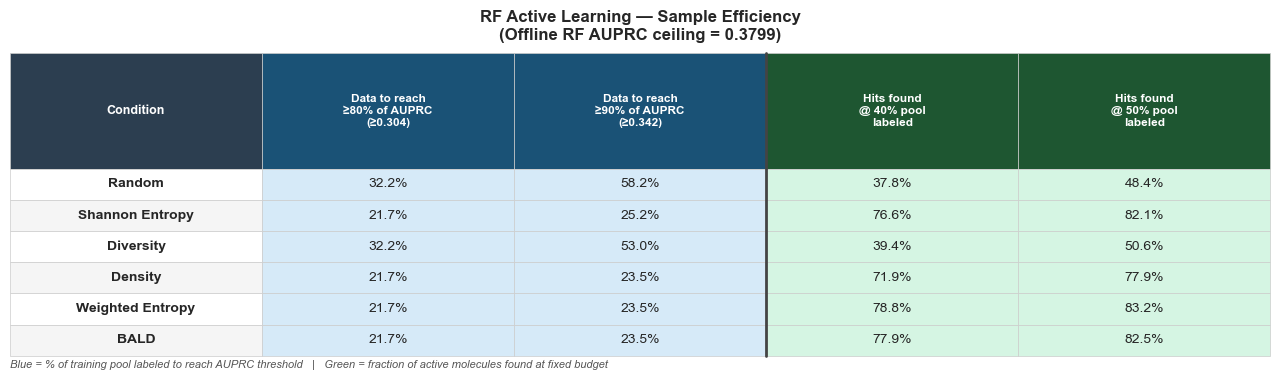

Saved: results/rf_efficiency_combined.png


In [12]:
# ── Revised Sample Efficiency Table ──────────────────────────────────────
# One combined table:
# Columns 1-2: % of pool to reach 80% and 90% of offline AUPRC
# Columns 3-4: Hit recovery at 40% and 50% pool budget
# No auto-highlighting (you will add stars manually)

def compute_combined_efficiency(passive_auprc, pool_size):
    rows = []
    for cond_key, style in CONDITIONS.items():
        if cond_key not in auprc_data or cond_key not in hits_data:
            continue

        df_auprc = get_mean_std(auprc_data[cond_key])
        df_hits  = get_mean_std(hits_data[cond_key])

        x_a    = df_auprc['n_labeled'].values
        mean_a = df_auprc['mean'].values
        x_h    = df_hits['n_labeled'].values
        mean_h = df_hits['mean'].values

        row = {'Condition': style['label']}

        # AUPRC columns — show as % of pool (not absolute molecules)
        for t in [0.80, 0.90]:
            target = t * passive_auprc
            idx    = np.where(mean_a >= target)[0]
            col    = f'Data to reach\n≥{int(t*100)}% of AUPRC\n(≥{target:.3f})'
            if len(idx) > 0:
                pct = x_a[idx[0]] / pool_size * 100
                row[col] = f'{pct:.1f}%'
            else:
                row[col] = '—'

        # Hit recovery columns at 40% and 50% pool
        for pct in [0.40, 0.50]:
            budget = int(pct * pool_size)
            val    = float(np.interp(budget, x_h, mean_h))
            row[f'Hits found\n@ {int(pct*100)}% pool\nlabeled'] = f'{val:.1%}'

        rows.append(row)

    return pd.DataFrame(rows).set_index('Condition')


combined_df = compute_combined_efficiency(PASSIVE_AUPRC, POOL_SIZE)
print(f'Offline RF AUPRC ceiling: {PASSIVE_AUPRC}')
display(combined_df)

# ── Render as figure ──────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

sub_df = combined_df.reset_index()
col_labels = sub_df.columns.tolist()
n_rows = len(sub_df)
n_cols = len(col_labels)

# Split columns into AUPRC group (cols 1-2) and Hits group (cols 3-4)
auprc_col_indices = [1, 2]   # 0-indexed in col_labels
hits_col_indices  = [3, 4]

table = ax.table(
    cellText=sub_df.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(10)

# Color palette
HEADER_DARK  = '#2c3e50'    # dark header for condition column
AUPRC_HEADER = '#1a5276'    # blue-dark for AUPRC header
HITS_HEADER  = '#1e5631'    # green-dark for hits header
AUPRC_BG     = '#d6eaf8'    # light blue for AUPRC data cells
HITS_BG      = '#d5f5e3'    # light green for hits data cells
ROW_EVEN     = '#f5f5f5'
ROW_ODD      = '#ffffff'

for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.5)

    if row_idx == 0:
        # Header row styling by column group
        if col_idx == 0:
            cell.set_facecolor(HEADER_DARK)
            cell.set_text_props(color='white', fontweight='bold', fontsize=9)
        elif col_idx in auprc_col_indices:
            cell.set_facecolor(AUPRC_HEADER)
            cell.set_text_props(color='white', fontweight='bold', fontsize=8.5)
        elif col_idx in hits_col_indices:
            cell.set_facecolor(HITS_HEADER)
            cell.set_text_props(color='white', fontweight='bold', fontsize=8.5)
        cell.set_height(0.20)   # taller header for wrapped text

    else:
        # Data rows
        base_bg = ROW_EVEN if row_idx % 2 == 0 else ROW_ODD
        if col_idx == 0:
            # Condition name column
            cell.set_facecolor(base_bg)
            cell.set_text_props(fontweight='bold', fontsize=10)
        elif col_idx in auprc_col_indices:
            cell.set_facecolor(AUPRC_BG)
            cell.set_text_props(fontsize=10)
        elif col_idx in hits_col_indices:
            cell.set_facecolor(HITS_BG)
            cell.set_text_props(fontsize=10)

# Add a vertical separator line between the two groups
# (visual only — drawn as a thick edge on the boundary column)
for row_idx in range(n_rows + 1):
    boundary_cell = table[row_idx, 2]   # last AUPRC column
    boundary_cell.visible_edges = 'BLTR'
    # Make right edge thicker by drawing a line
    # (matplotlib table doesn't support per-edge width, so we use a line)

# Draw a vertical line to visually separate AUPRC vs Hits columns
# With this — draws a vertical line in axis (0-1) coordinates
# The separator sits between column 2 (last AUPRC) and column 3 (first Hits)
# Estimate its x position as fraction: 3 columns out of 5 total = 0.60
separator_frac = (3) / n_cols   # fraction of table width after first 3 columns
ax.plot([separator_frac, separator_frac], [0, 1],
        transform=ax.transAxes,
        color='#444444', linewidth=2.0,
        clip_on=False, zorder=10)

# Legend annotation
ax.text(0.0, -0.04,
        'Blue = % of training pool labeled to reach AUPRC threshold   '
        '|   Green = fraction of active molecules found at fixed budget',
        transform=ax.transAxes, fontsize=8, color='#555', style='italic')

ax.set_title(
    f'RF Active Learning — Sample Efficiency\n'
    f'(Offline RF AUPRC ceiling = {PASSIVE_AUPRC})',
    fontsize=12, fontweight='bold', pad=10
)

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'rf_efficiency_combined.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

In [9]:
# ── Summary: which conditions completed and file list ─────────────────────
import glob

saved = sorted(glob.glob(os.path.join(RESULTS_DIR, 'rf_*.png')))
print('Generated figures:')
for f in saved:
    size_kb = os.path.getsize(f) // 1024
    print(f'  {f}  ({size_kb} KB)')

print()
print('Conditions plotted:', list(CONDITIONS.keys()))
print('Missing from data:', [k for k in CONDITIONS if k not in auprc_data])

Generated figures:
  results/rf_auprc_hits_2panel.png  (342 KB)
  results/rf_early_budget_zoom.png  (346 KB)
  results/rf_efficiency_tables.png  (153 KB)
  results/rf_learning_curves.png  (607 KB)

Conditions plotted: ['rf_random', 'rf_entropy', 'rf_diversity', 'rf_density', 'rf_weighted', 'rf_bald']
Missing from data: []


## MPNN

In [16]:
# ══════════════════════════════════════════════════════════════════════════
# MPNN RESULTS — New section
# ══════════════════════════════════════════════════════════════════════════

# ── Config ────────────────────────────────────────────────────────────────
MPNN_FILE       = 'preprocessing/data/All_Runs_Metrics.xlsx'
MPNN_AUPRC_TAB  = 'MPNN - AUPRC'
MPNN_HITS_TAB   = 'MPNN - Hits'

# Passive MPNN baseline (from Cell A4)
MPNN_PASSIVE_AUPRC = 0.3027
MPNN_PASSIVE_AUROC = 0.7643   # update if you have this value

# Conditions in this file — column names as they appear in the Excel header
# Map Excel header → display label, color, linestyle
MPNN_CONDITIONS = {
    'Entropy':  {'label': 'Shannon Entropy', 'color': '#1f77b4', 'linestyle': '-',  'zorder': 3},
    'Weighted': {'label': 'Weighted Entropy', 'color': '#d62728', 'linestyle': '-',  'zorder': 4},
    'BALD':     {'label': 'BALD',             'color': '#ff7f0e', 'linestyle': '-',  'zorder': 4},
    'Diversity':{'label': 'Diversity',         'color': '#9467bd', 'linestyle': '--', 'zorder': 2},
    'Density':  {'label': 'Density',           'color': '#8c564b', 'linestyle': '-.', 'zorder': 2},
    'Random':   {'label': 'Random',            'color': '#808080', 'linestyle': ':',  'zorder': 1},
}

print('MPNN config loaded.')
print(f'  Passive MPNN AUPRC : {MPNN_PASSIVE_AUPRC}')
print(f'  File               : {MPNN_FILE}')

MPNN config loaded.
  Passive MPNN AUPRC : 0.3027
  File               : preprocessing/data/All_Runs_Metrics.xlsx


In [17]:
# ── Load MPNN data ─────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

def load_mpnn_tab(filepath, sheet_name):
    """
    Load one tab from All_Runs_Metrics.xlsx.
    
    Structure (from screenshot):
      Row 0    = header: Iteration | Training Data Amount | Percent... | Diversity | Density | Entropy | Weighted | BALD | Random
      Rows 1-N = data rows (N ~ 48 iterations)
      Bottom rows = metadata text (skip these)
    
    Returns DataFrame with columns: [n_labeled, Entropy, Weighted, BALD, Diversity, Density, Random]
    """
    df = pd.read_excel(filepath, sheet_name=sheet_name, header=0)
    
    print(f"  Raw shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  First 3 rows:\n{df.head(3)}")
    
    # The second column contains n_labeled (Training Data Amount)
    # Keep only rows where that column is numeric (skip metadata rows at bottom)
    n_labeled_col = df.columns[1]   # 'Training Data Amount'
    df = df[pd.to_numeric(df[n_labeled_col], errors='coerce').notna()].copy()
    df[n_labeled_col] = df[n_labeled_col].astype(float).astype(int)
    
    # Rename n_labeled column
    df = df.rename(columns={n_labeled_col: 'n_labeled'})
    
    # Keep only the condition columns + n_labeled
    keep_cols = ['n_labeled'] + [c for c in df.columns if c in MPNN_CONDITIONS]
    df = df[keep_cols].sort_values('n_labeled').reset_index(drop=True)
    
    # Convert all condition columns to float
    for col in df.columns:
        if col != 'n_labeled':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df


print("Loading MPNN data...")
mpnn_auprc = load_mpnn_tab(MPNN_FILE, MPNN_AUPRC_TAB)
mpnn_hits  = load_mpnn_tab(MPNN_FILE, MPNN_HITS_TAB)

print(f"\nMPNN AUPRC: {mpnn_auprc.shape}, n_labeled {mpnn_auprc['n_labeled'].min()}→{mpnn_auprc['n_labeled'].max()}")
print(f"MPNN Hits:  {mpnn_hits.shape}")
print(f"Conditions found: {[c for c in mpnn_auprc.columns if c != 'n_labeled']}")
display(mpnn_auprc.head(4))

Loading MPNN data...
  Raw shape: (959, 9)
  Columns: ['Iteration', 'Training Data Amount', 'Percent of Training Pool in Training Data', 'Diversity', 'Density', 'Entropy', 'Weighted', 'Bald', 'Random']
  First 3 rows:
  Iteration  Training Data Amount Percent of Training Pool in Training Data  \
0         0                5757.0                                 19.997916   
1         1                6257.0                                 21.734751   
2         2                6757.0                                 23.471585   

   Diversity   Density   Entropy  Weighted      Bald    Random  
0   0.105476  0.113829  0.105803  0.113744  0.137218  0.087593  
1   0.100015  0.137685  0.168929  0.158303  0.121779  0.139589  
2   0.112239  0.157181  0.176146  0.196464  0.155160  0.110785  
  Raw shape: (51, 9)
  Columns: ['Iteration', 'Training Data Amount', 'Percent of Training Pool in Training Data', 'Diversity', 'Density', 'Entropy', 'Weighted', 'Bald', 'Random']
  First 3 rows:
   Iterat

,n_labeled,Diversity,Density,Entropy,Weighted,Random
0,5757,0.105476,0.113829,0.105803,0.113744,0.087593
1,6257,0.100015,0.137685,0.168929,0.158303,0.139589
2,6757,0.112239,0.157181,0.176146,0.196464,0.110785
3,7257,0.139796,0.181801,0.197356,0.222749,0.153295


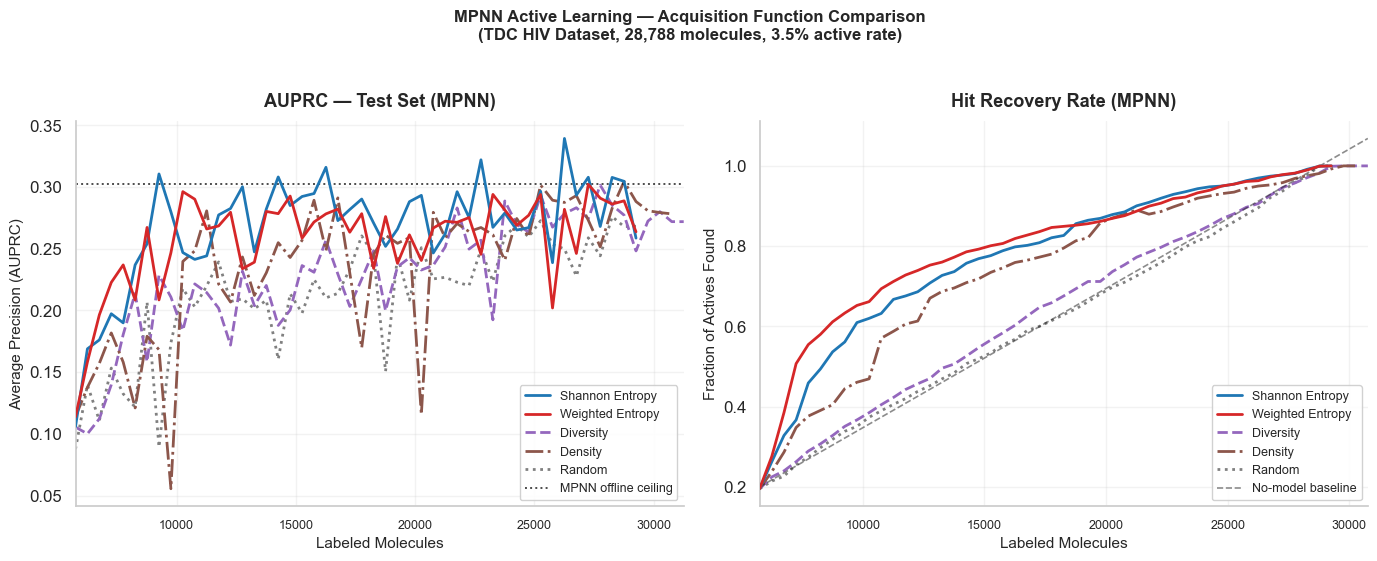

Saved: results/mpnn_learning_curves.png


In [18]:
# ── Figure: MPNN Learning Curves (AUPRC + Hit Recovery) ──────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, df, title, ylabel, passive_val in [
    (axes[0], mpnn_auprc, 'AUPRC — Test Set (MPNN)',      'Average Precision (AUPRC)', MPNN_PASSIVE_AUPRC),
    (axes[1], mpnn_hits,  'Hit Recovery Rate (MPNN)',      'Fraction of Actives Found', None),
]:
    x = df['n_labeled'].values
    
    for cond_col, style in MPNN_CONDITIONS.items():
        if cond_col not in df.columns:
            continue
        y = df[cond_col].values
        # Mask NaN
        mask = ~np.isnan(y)
        ax.plot(x[mask], y[mask],
                label=style['label'],
                color=style['color'],
                linestyle=style['linestyle'],
                linewidth=2.0,
                zorder=style['zorder'])
        # Note: since this is averaged (no per-seed std), no shading band
        # If you have per-seed data later, you can add fill_between here

    if passive_val is not None:
        ax.axhline(passive_val, color='black', linestyle=':',
                   linewidth=1.4, alpha=0.7, label='MPNN offline ceiling')

    if title.startswith('Hit'):
        x_r = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_r, x_r / POOL_SIZE, 'k--', lw=1.2, alpha=0.5, label='No-model baseline')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Labeled Molecules', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, framealpha=0.9, loc='lower right')
    ax.set_xlim(x.min(), x.max())
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle(
    'MPNN Active Learning — Acquisition Function Comparison\n'
    f'(TDC HIV Dataset, {POOL_SIZE:,} molecules, 3.5% active rate)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'mpnn_learning_curves.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

Offline (Passive) MPNN AUPRC: 0.3027


,Data to reach\n≥80% AUPRC\n(≥0.242),Data to reach\n≥90% AUPRC\n(≥0.272),Hits found\n@ 40% pool\nlabeled,Hits found\n@ 50% pool\nlabeled
Condition,,,,
Shannon Entropy,30.4%,32.2%,67.2%,76.0%
Weighted Entropy,30.4%,35.6%,72.0%,78.8%
Diversity,56.5%,75.6%,43.3%,53.2%
Density,37.4%,39.1%,59.7%,71.2%
Random,61.7%,87.7%,41.3%,51.0%


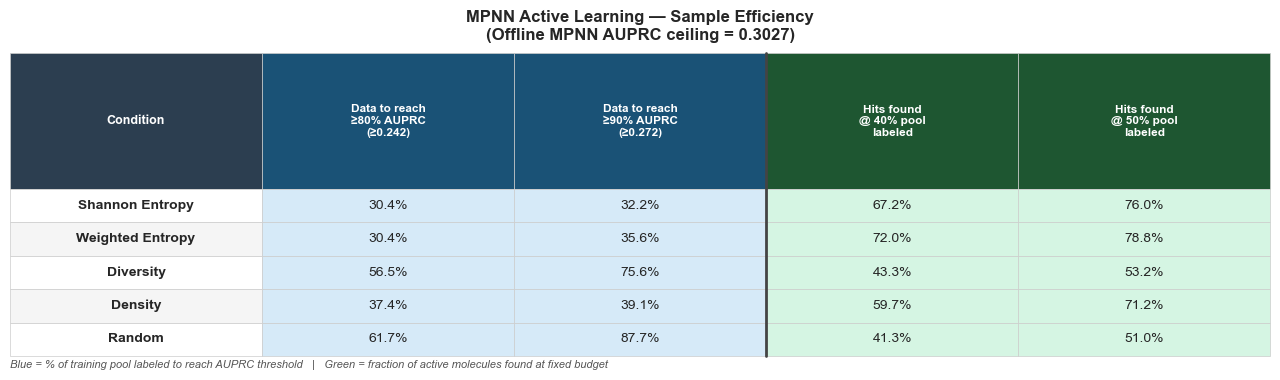

Saved: results/mpnn_efficiency_table.png


In [19]:
# ── MPNN Sample Efficiency Table ──────────────────────────────────────────

def compute_mpnn_efficiency(passive_auprc, pool_size):
    rows = []
    x_a = mpnn_auprc['n_labeled'].values
    x_h = mpnn_hits['n_labeled'].values

    for cond_col, style in MPNN_CONDITIONS.items():
        if cond_col not in mpnn_auprc.columns:
            continue

        mean_a = mpnn_auprc[cond_col].values
        mean_h = mpnn_hits[cond_col].values

        row = {'Condition': style['label']}

        # % of pool to reach 80% and 90% of passive AUPRC ceiling
        for t in [0.80, 0.90]:
            target = t * passive_auprc
            valid  = ~np.isnan(mean_a)
            idx    = np.where((mean_a >= target) & valid)[0]
            col    = f'Data to reach\n≥{int(t*100)}% AUPRC\n(≥{target:.3f})'
            if len(idx) > 0:
                pct = x_a[idx[0]] / pool_size * 100
                row[col] = f'{pct:.1f}%'
            else:
                row[col] = '—'

        # Hit recovery at 40% and 50% of pool
        for pct in [0.40, 0.50]:
            budget = int(pct * pool_size)
            valid  = ~np.isnan(mean_h)
            if valid.sum() > 1:
                val = float(np.interp(budget, x_h[valid], mean_h[valid]))
                row[f'Hits found\n@ {int(pct*100)}% pool\nlabeled'] = f'{val:.1%}'
            else:
                row[f'Hits found\n@ {int(pct*100)}% pool\nlabeled'] = '—'

        rows.append(row)

    return pd.DataFrame(rows).set_index('Condition')


mpnn_efficiency_df = compute_mpnn_efficiency(MPNN_PASSIVE_AUPRC, POOL_SIZE)
print(f'Offline (Passive) MPNN AUPRC: {MPNN_PASSIVE_AUPRC}')
display(mpnn_efficiency_df)

# ── Render as figure ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

sub_df  = mpnn_efficiency_df.reset_index()
n_cols  = len(sub_df.columns)
n_rows  = len(sub_df)
col_labels = sub_df.columns.tolist()

auprc_col_indices = [1, 2]
hits_col_indices  = [3, 4]

HEADER_DARK  = '#2c3e50'
AUPRC_HEADER = '#1a5276'
HITS_HEADER  = '#1e5631'
AUPRC_BG     = '#d6eaf8'
HITS_BG      = '#d5f5e3'

table = ax.table(
    cellText=sub_df.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(10)

for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.5)
    if row_idx == 0:
        if col_idx == 0:
            cell.set_facecolor(HEADER_DARK)
            cell.set_text_props(color='white', fontweight='bold', fontsize=9)
        elif col_idx in auprc_col_indices:
            cell.set_facecolor(AUPRC_HEADER)
            cell.set_text_props(color='white', fontweight='bold', fontsize=8.5)
        elif col_idx in hits_col_indices:
            cell.set_facecolor(HITS_HEADER)
            cell.set_text_props(color='white', fontweight='bold', fontsize=8.5)
        cell.set_height(0.22)
    else:
        base = '#f5f5f5' if row_idx % 2 == 0 else '#ffffff'
        if col_idx == 0:
            cell.set_facecolor(base)
            cell.set_text_props(fontweight='bold', fontsize=10)
        elif col_idx in auprc_col_indices:
            cell.set_facecolor(AUPRC_BG)
        elif col_idx in hits_col_indices:
            cell.set_facecolor(HITS_BG)

# Separator line between AUPRC and Hits columns
separator_frac = 3 / n_cols
ax.plot([separator_frac, separator_frac], [0, 1],
        transform=ax.transAxes, color='#444444',
        linewidth=2.0, clip_on=False, zorder=10)

ax.text(0.0, -0.04,
        'Blue = % of training pool labeled to reach AUPRC threshold   '
        '|   Green = fraction of active molecules found at fixed budget',
        transform=ax.transAxes, fontsize=8, color='#555', style='italic')

ax.set_title(
    f'MPNN Active Learning — Sample Efficiency\n'
    f'(Offline MPNN AUPRC ceiling = {MPNN_PASSIVE_AUPRC})',
    fontsize=12, fontweight='bold', pad=10
)

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'mpnn_efficiency_table.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## MPNN Metrics and Figures for Final Report

Loading MPNN Excel files (new format)...
  Loaded 'mpnn_density': 48 rows, 4 seed(s)
  Loaded 'mpnn_diversity': 48 rows, 4 seed(s)
  Loaded 'mpnn_random': 48 rows, 4 seed(s)
  Loaded 'mpnn_weighted': 48 rows, 4 seed(s)
  Loaded 'mpnn_entropy': 48 rows, 4 seed(s)
  Loaded 'mpnn_bald': 48 rows, 1 seed(s)
  Loaded 'mpnn_EI': 48 rows, 4 seed(s)
  Loaded 'mpnn_density': 48 rows, 4 seed(s)
  Loaded 'mpnn_diversity': 48 rows, 4 seed(s)
  Loaded 'mpnn_random': 48 rows, 4 seed(s)
  Loaded 'mpnn_weighted': 48 rows, 4 seed(s)
  Loaded 'mpnn_entropy': 48 rows, 4 seed(s)
  SKIPPING 'mpnn_bald': empty or too few columns
  Loaded 'mpnn_EI': 48 rows, 4 seed(s)
  Loaded 'mpnn_density': 48 rows, 4 seed(s)
  Loaded 'mpnn_diversity': 48 rows, 4 seed(s)
  Loaded 'mpnn_random': 48 rows, 4 seed(s)
  Loaded 'mpnn_weighted': 48 rows, 4 seed(s)
  Loaded 'mpnn_entropy': 48 rows, 4 seed(s)
  SKIPPING 'mpnn_bald': empty or too few columns
  Loaded 'mpnn_EI': 48 rows, 4 seed(s)

Sheets in AUPRC file: ['mpnn_density

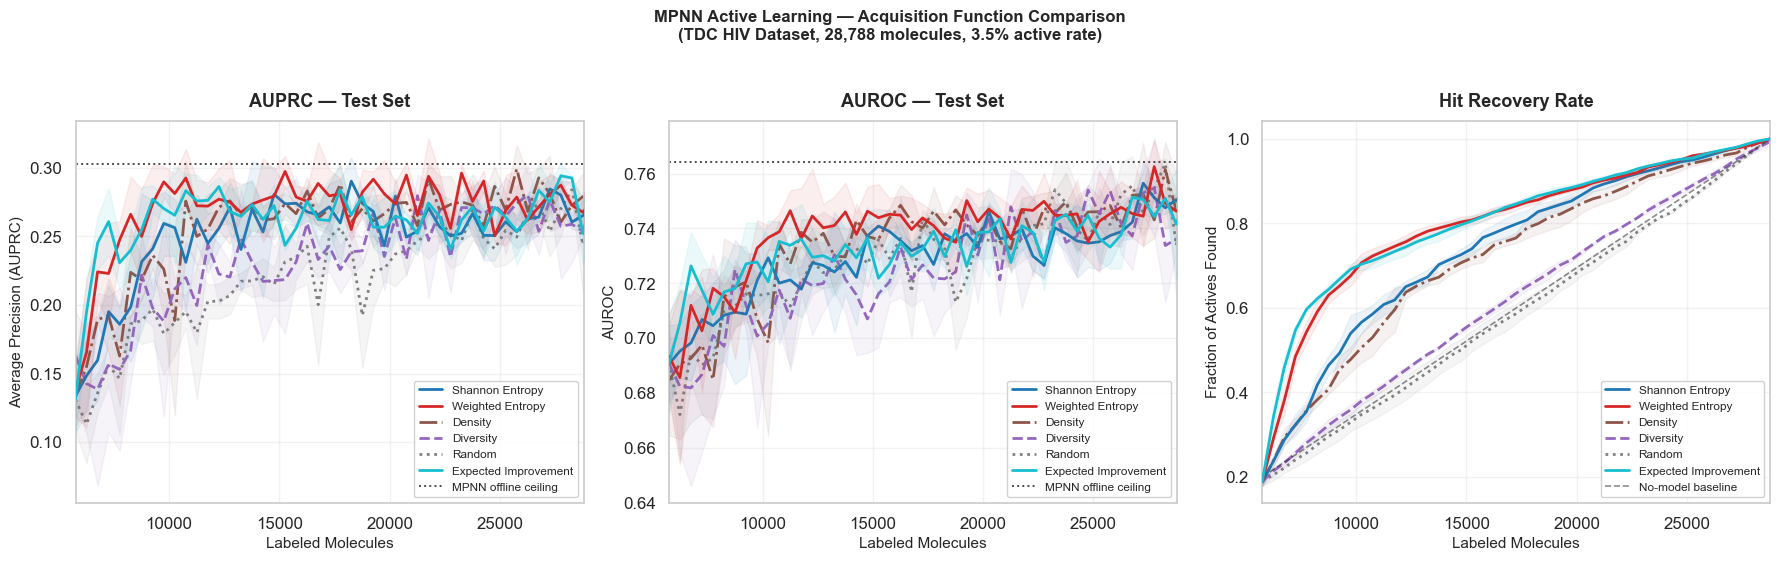

Saved: results/mpnn_learning_curves_v2.png


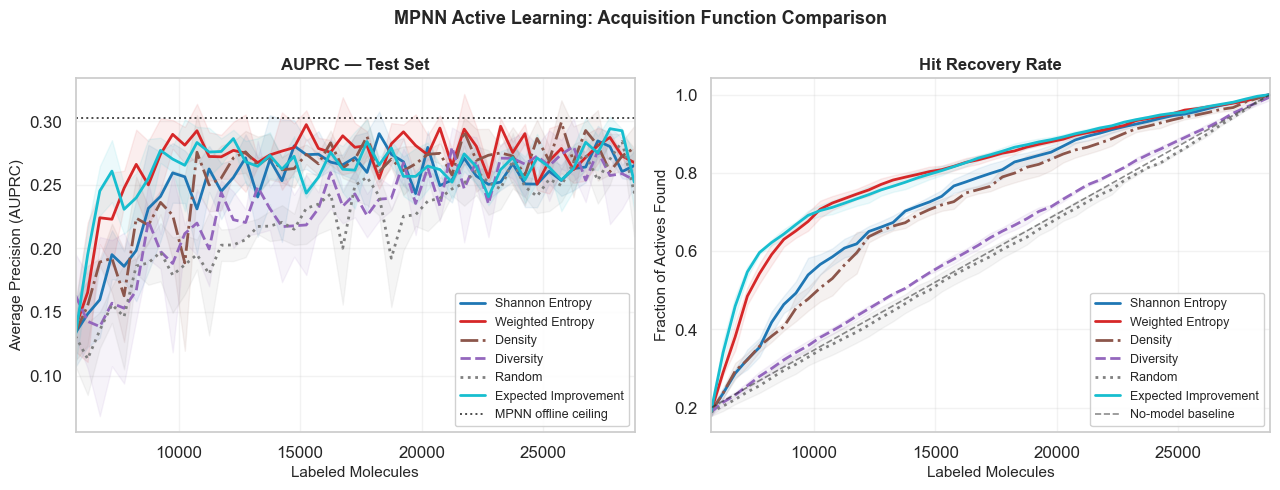

Saved: results/mpnn_auprc_hits_2panel_v2.png

MPNN Offline AUPRC ceiling: 0.3027


,Data to reach\n≥80% AUPRC\n(≥0.242),Data to reach\n≥90% AUPRC\n(≥0.272),Hits found\n@ 40% pool\nlabeled,Hits found\n@ 50% pool\nlabeled
Condition,,,,
Shannon Entropy,33.9%,51.3%,61.3%,71.7%
Weighted Entropy,26.9%,32.2%,74.0%,79.8%
Density,37.4%,37.4%,58.1%,69.6%
Diversity,40.8%,73.8%,42.5%,53.1%
Random,56.5%,92.9%,38.6%,49.0%
Expected Improvement,23.5%,32.2%,72.8%,79.0%


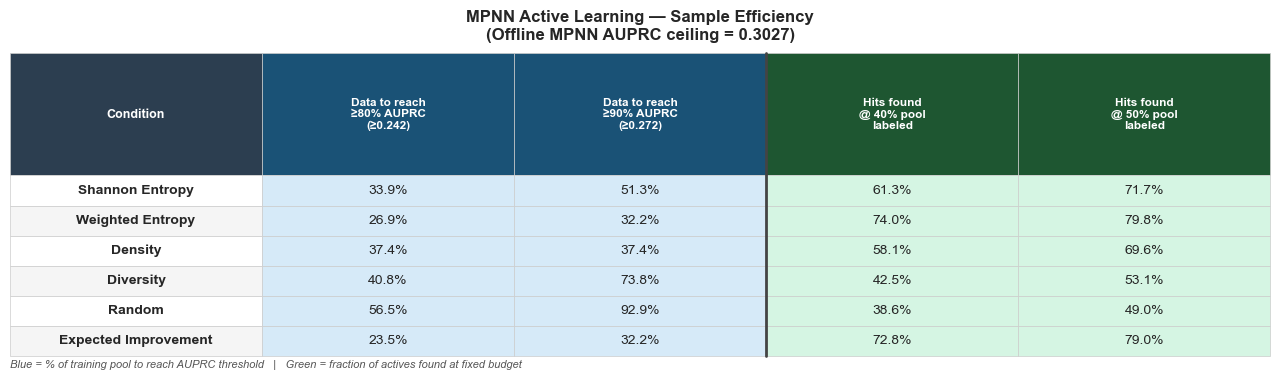

Saved: results/mpnn_efficiency_table_v2.png


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# MPNN RESULTS — New format (separate xlsx files, same as RF)
# Files: mpnn_auprc_all_seeds.xlsx, mpnn_auroc_all_seeds.xlsx,
#        mpnn_hit_recovery_all_seeds.xlsx
# Tab names: mpnn_density, mpnn_diversity, mpnn_random,
#            mpnn_weighted, mpnn_entropy, mpnn_bald, mpnn_EI
# Column structure: Step | seed0_col | seed1_col | seed2_col
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', font_scale=1.1)

# ── Config ────────────────────────────────────────────────────────────────
MPNN_AUPRC_FILE = os.path.join(DATA_DIR, 'mpnn_auprc_all_seeds.xlsx')
MPNN_AUROC_FILE = os.path.join(DATA_DIR, 'mpnn_auroc_all_seeds.xlsx')
MPNN_HITS_FILE  = os.path.join(DATA_DIR, 'mpnn_hit_recovery_all_seeds.xlsx')

MPNN_PASSIVE_AUPRC = 0.3027
MPNN_PASSIVE_AUROC = 0.7643

N_INIT_MPNN    = 5757
BATCH_MPNN     = 500
POOL_SIZE_MPNN = 28788

# Conditions — tab names in the MPNN Excel files
MPNN_CONDITIONS_NEW = {
    'mpnn_entropy':  {'label': 'Shannon Entropy', 'color': '#1f77b4', 'ls': '-',  'zorder': 3},
    'mpnn_weighted': {'label': 'Weighted Entropy', 'color': '#d62728', 'ls': '-',  'zorder': 4},
    #'mpnn_bald':     {'label': 'BALD',             'color': '#ff7f0e', 'ls': '-',  'zorder': 4},
    'mpnn_density':  {'label': 'Density',           'color': '#8c564b', 'ls': '-.', 'zorder': 2},
    'mpnn_diversity':{'label': 'Diversity',          'color': '#9467bd', 'ls': '--', 'zorder': 2},
    'mpnn_random':   {'label': 'Random',             'color': '#808080', 'ls': ':',  'zorder': 1},
    'mpnn_EI':       {'label': 'Expected Improvement','color': '#17becf', 'ls': '-', 'zorder': 4},
}

# ── Load function (same structure as RF) ──────────────────────────────────
def load_mpnn_metric_file(filepath):
    """
    Load all sheets from an MPNN Excel file.
    Structure matches RF: Step col + seed columns.
    Returns dict: {sheet_name: DataFrame with [step, seed0, seed1, ..., n_labeled]}
    """
    all_sheets = pd.read_excel(filepath, sheet_name=None, index_col=None)
    result = {}
    for sheet_name, df in all_sheets.items():
        if df.empty or len(df.columns) < 2:
            print(f"  SKIPPING '{sheet_name}': empty or too few columns")
            continue
        cols = df.columns.tolist()
        rename = {cols[0]: 'step'}
        for i, c in enumerate(cols[1:]):
            rename[c] = f'seed{i}'
        df = df.rename(columns=rename)
        try:
            df['step'] = pd.to_numeric(df['step'], errors='coerce')
            df = df.dropna(subset=['step'])
            df['step'] = df['step'].astype(int)
        except Exception as e:
            print(f"  SKIPPING '{sheet_name}': {e}")
            continue
        if len(df) == 0:
            continue
        df['n_labeled'] = df['step'].map(lambda s: N_INIT_MPNN + s * BATCH_MPNN)
        result[sheet_name] = df
        n_seeds = len([c for c in df.columns if c.startswith('seed')])
        print(f"  Loaded '{sheet_name}': {len(df)} rows, {n_seeds} seed(s)")
    return result


def get_mpnn_mean_std(df):
    seed_cols = [c for c in df.columns if c.startswith('seed')]
    df = df.copy().sort_values('n_labeled')
    df['mean'] = df[seed_cols].mean(axis=1)
    df['std']  = df[seed_cols].std(axis=1)
    return df


print('Loading MPNN Excel files (new format)...')
mpnn_auprc_data = load_mpnn_metric_file(MPNN_AUPRC_FILE)
mpnn_auroc_data = load_mpnn_metric_file(MPNN_AUROC_FILE)
mpnn_hits_data  = load_mpnn_metric_file(MPNN_HITS_FILE)

print(f'\nSheets in AUPRC file: {list(mpnn_auprc_data.keys())}')

# ── Figure 1: 3-panel learning curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for data_dict, ax, title, ylabel, passive_val, passive_label in [
    (mpnn_auprc_data, axes[0], 'AUPRC — Test Set', 'Average Precision (AUPRC)',
     MPNN_PASSIVE_AUPRC, 'MPNN offline ceiling'),
    (mpnn_auroc_data, axes[1], 'AUROC — Test Set', 'AUROC',
     MPNN_PASSIVE_AUROC, 'MPNN offline ceiling'),
    (mpnn_hits_data,  axes[2], 'Hit Recovery Rate', 'Fraction of Actives Found',
     None, None),
]:
    for cond_key, style in MPNN_CONDITIONS_NEW.items():
        if cond_key not in data_dict:
            continue
        df = get_mpnn_mean_std(data_dict[cond_key])
        ax.plot(df['n_labeled'], df['mean'],
                label=style['label'], color=style['color'],
                linestyle=style['ls'], linewidth=2.0, zorder=style['zorder'])
        ax.fill_between(df['n_labeled'],
                        df['mean'] - df['std'],
                        df['mean'] + df['std'],
                        color=style['color'], alpha=0.08,
                        zorder=style['zorder'] - 1)

    if passive_val is not None:
        ax.axhline(passive_val, color='black', linestyle=':', lw=1.4,
                   alpha=0.7, label=passive_label)

    if title == 'Hit Recovery Rate':
        x_r = np.linspace(N_INIT_MPNN, POOL_SIZE_MPNN, 200)
        ax.plot(x_r, x_r / POOL_SIZE_MPNN, 'k--', lw=1.2,
                alpha=0.5, label='No-model baseline')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Labeled Molecules', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=8.5, framealpha=0.9, loc='lower right')
    ax.set_xlim(N_INIT_MPNN, POOL_SIZE_MPNN)
    ax.grid(True, alpha=0.25)

plt.suptitle(
    'MPNN Active Learning — Acquisition Function Comparison\n'
    f'(TDC HIV Dataset, {POOL_SIZE_MPNN:,} molecules, 3.5% active rate)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
out1 = os.path.join(RESULTS_DIR, 'mpnn_learning_curves_v2.png')
plt.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out1}')

# ── Figure 2: 2-panel AUPRC + Hits (paper-ready) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for data_dict, ax, title, ylabel, passive_val in [
    (mpnn_auprc_data, axes[0], 'AUPRC — Test Set', 'Average Precision (AUPRC)', MPNN_PASSIVE_AUPRC),
    (mpnn_hits_data,  axes[1], 'Hit Recovery Rate', 'Fraction of Actives Found', None),
]:
    for cond_key, style in MPNN_CONDITIONS_NEW.items():
        if cond_key not in data_dict:
            continue
        df = get_mpnn_mean_std(data_dict[cond_key])
        ax.plot(df['n_labeled'], df['mean'],
                label=style['label'], color=style['color'],
                linestyle=style['ls'], linewidth=2.0)
        ax.fill_between(df['n_labeled'],
                        df['mean'] - df['std'],
                        df['mean'] + df['std'],
                        color=style['color'], alpha=0.08)

    if passive_val is not None:
        ax.axhline(passive_val, color='black', linestyle=':', lw=1.4,
                   alpha=0.7, label='MPNN offline ceiling')
    if title == 'Hit Recovery Rate':
        x_r = np.linspace(N_INIT_MPNN, POOL_SIZE_MPNN, 200)
        ax.plot(x_r, x_r / POOL_SIZE_MPNN, 'k--', lw=1.2,
                alpha=0.5, label='No-model baseline')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Labeled Molecules', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.set_xlim(N_INIT_MPNN, POOL_SIZE_MPNN)
    ax.grid(True, alpha=0.25)

plt.suptitle('MPNN Active Learning: Acquisition Function Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out2 = os.path.join(RESULTS_DIR, 'mpnn_auprc_hits_2panel_v2.png')
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out2}')

# ── Sample Efficiency Table ────────────────────────────────────────────────
def compute_mpnn_efficiency_v2(passive_auprc, pool_size):
    rows = []
    for cond_key, style in MPNN_CONDITIONS_NEW.items():
        if cond_key not in mpnn_auprc_data or cond_key not in mpnn_hits_data:
            continue
        df_a = get_mpnn_mean_std(mpnn_auprc_data[cond_key])
        df_h = get_mpnn_mean_std(mpnn_hits_data[cond_key])
        x_a, mean_a = df_a['n_labeled'].values, df_a['mean'].values
        x_h, mean_h = df_h['n_labeled'].values, df_h['mean'].values
        row = {'Condition': style['label']}
        for t in [0.80, 0.90]:
            target = t * passive_auprc
            valid  = ~np.isnan(mean_a)
            idx    = np.where((mean_a >= target) & valid)[0]
            col    = f'Data to reach\n≥{int(t*100)}% AUPRC\n(≥{target:.3f})'
            row[col] = f'{x_a[idx[0]]/pool_size*100:.1f}%' if len(idx) > 0 else '—'
        for pct in [0.40, 0.50]:
            budget = int(pct * pool_size)
            valid  = ~np.isnan(mean_h)
            if valid.sum() > 1:
                val = float(np.interp(budget, x_h[valid], mean_h[valid]))
                row[f'Hits found\n@ {int(pct*100)}% pool\nlabeled'] = f'{val:.1%}'
            else:
                row[f'Hits found\n@ {int(pct*100)}% pool\nlabeled'] = '—'
        rows.append(row)
    return pd.DataFrame(rows).set_index('Condition')

mpnn_eff_df = compute_mpnn_efficiency_v2(MPNN_PASSIVE_AUPRC, POOL_SIZE_MPNN)
print(f'\nMPNN Offline AUPRC ceiling: {MPNN_PASSIVE_AUPRC}')
display(mpnn_eff_df)

# ── Render efficiency table as figure ─────────────────────────────────────
HEADER_DARK  = '#2c3e50'
AUPRC_HEADER = '#1a5276'
HITS_HEADER  = '#1e5631'
AUPRC_BG     = '#d6eaf8'
HITS_BG      = '#d5f5e3'
n_auprc_cols = 2
n_hits_cols  = 2

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')
sub_df   = mpnn_eff_df.reset_index()
n_cols   = len(sub_df.columns)
n_rows   = len(sub_df)
auprc_ci = [1, 2]
hits_ci  = [3, 4]

table = ax.table(
    cellText=sub_df.values,
    colLabels=sub_df.columns.tolist(),
    cellLoc='center', loc='center', bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(10)

for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.5)
    if row_idx == 0:
        if col_idx == 0:
            cell.set_facecolor(HEADER_DARK)
            cell.set_text_props(color='white', fontweight='bold', fontsize=9)
        elif col_idx in auprc_ci:
            cell.set_facecolor(AUPRC_HEADER)
            cell.set_text_props(color='white', fontweight='bold', fontsize=8.5)
        elif col_idx in hits_ci:
            cell.set_facecolor(HITS_HEADER)
            cell.set_text_props(color='white', fontweight='bold', fontsize=8.5)
        cell.set_height(0.22)
    else:
        base = '#f5f5f5' if row_idx % 2 == 0 else '#ffffff'
        if col_idx == 0:
            cell.set_facecolor(base)
            cell.set_text_props(fontweight='bold', fontsize=10)
        elif col_idx in auprc_ci:
            cell.set_facecolor(AUPRC_BG)
        elif col_idx in hits_ci:
            cell.set_facecolor(HITS_BG)

# Separator line between AUPRC and Hits columns
sep = 3 / n_cols
ax.plot([sep, sep], [0, 1], transform=ax.transAxes,
        color='#444444', linewidth=2.0, clip_on=False, zorder=10)

ax.text(0.0, -0.04,
        'Blue = % of training pool to reach AUPRC threshold   '
        '|   Green = fraction of actives found at fixed budget',
        transform=ax.transAxes, fontsize=8, color='#555', style='italic')

ax.set_title(
    f'MPNN Active Learning — Sample Efficiency\n'
    f'(Offline MPNN AUPRC ceiling = {MPNN_PASSIVE_AUPRC})',
    fontsize=12, fontweight='bold', pad=10
)
plt.tight_layout()
out3 = os.path.join(RESULTS_DIR, 'mpnn_efficiency_table_v2.png')
plt.savefig(out3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out3}')